In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from os import listdir
from utils_Nankai import CoplanarFaultModelOutput
# set font size
plt.rcParams.update({'font.size': 12})

In [2]:
main_dir =  "Nankai_output"
model_output_dir = "constant_instability_fixed_b"

files_interest = listdir(main_dir+ "/" + model_output_dir + "/")
files_interest = ["/" + model_output_dir + "/"+f for f in files_interest]
files_interest = [f for f in files_interest if not f.endswith('.DS_Store')]

example_output = ["/Dc_008_strong_barrier/"+listdir(main_dir+"/Dc_008_strong_barrier/")[i] for i in [-1, -2]]

Dc = 0.008 

run_test = False
plot_all = False

In [3]:
# tests:
if run_test:
    filename = main_dir + files_interest[-1]
    model = CoplanarFaultModelOutput(filename, Dc=Dc)
    # ax = model.plot_grid("log10v", crop=0.3) 
    # ax.set_title(f"L1/L2 = {model.L1/model.L2}")
    catalog = model.make_catalog()
    model.estimate_coupling("1_to_2", system_spanning=True, system_spanning_threshold=1)
    model.plot_catalog()

[(7116.9, 10167.0),
 Text(0.5, 814.069105691057, ''),
 Text(845.678861788618, 0.5, '')]

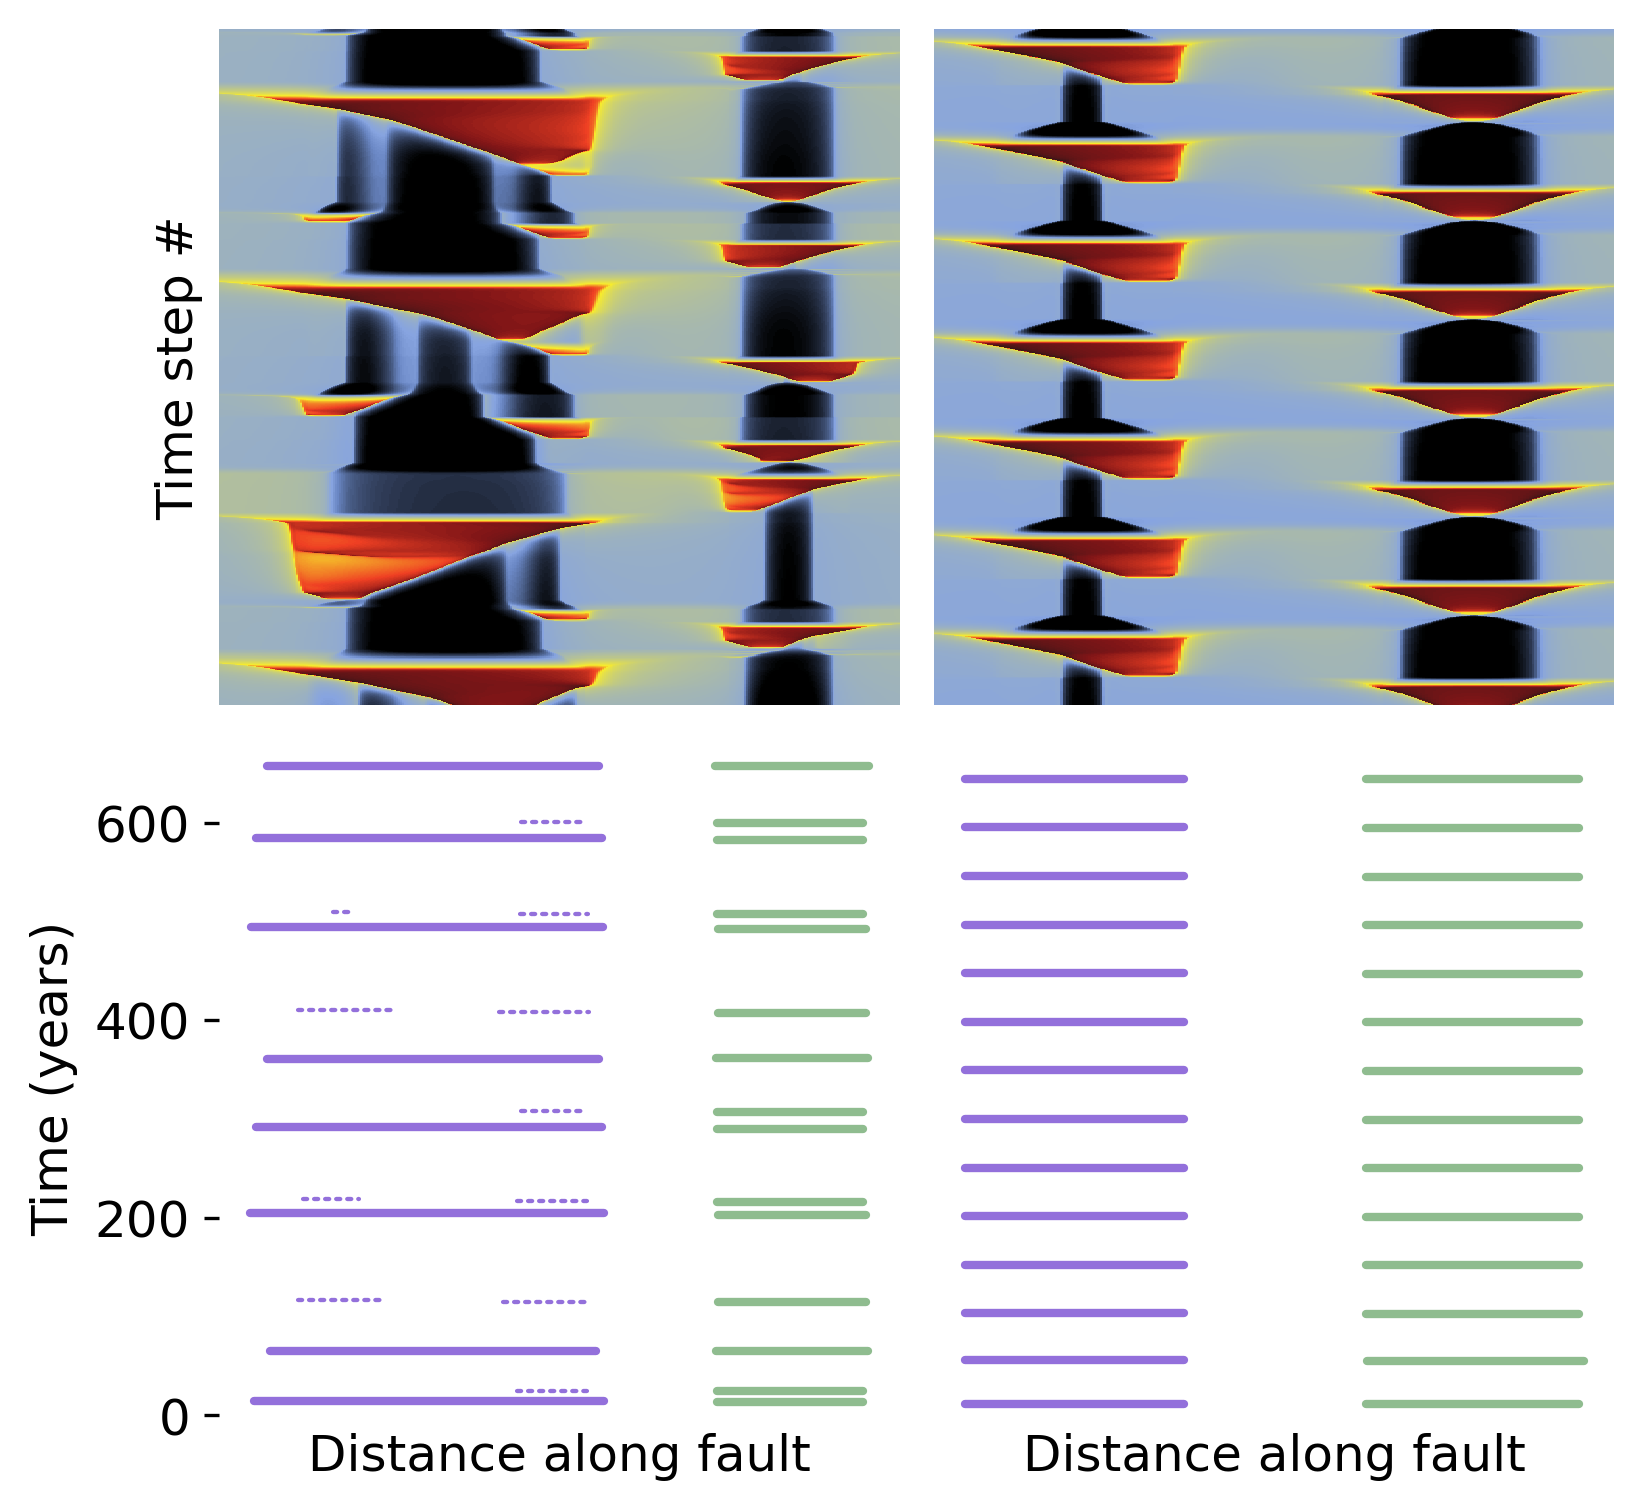

In [4]:
# example #1: 
model = CoplanarFaultModelOutput("Nankai_output"+example_output[0], Dc=Dc)
fig, AX = plt.subplots(2, 2, figsize=(6, 6), dpi=300, gridspec_kw={'hspace':0.05, 'wspace':0.05})

ax = AX[1,0]
catalog1, catalog2 = model.get_catalogs()
system_spanning_catalog1 = catalog1[catalog1["length_km"] > model.L1/1000 * 1]
system_spanning_catalog2 = catalog2[catalog2["length_km"] > model.L2/1000 * 1]

def plot_bars(ax, catalog, kwargs):
    # Ensure catalog index is reset to integer range, avoiding KeyError when accessing by position
    catalog_reset = catalog.reset_index(drop=True)
    for i in range(len(catalog_reset)):
        ax.plot(
            [
                catalog_reset.loc[i, "midpoint_index"] - catalog_reset.loc[i, "length_pixels"]/2,
                catalog_reset.loc[i, "midpoint_index"] + catalog_reset.loc[i, "length_pixels"]/2
            ],
            [catalog_reset.loc[i, "start_time"], catalog_reset.loc[i, "start_time"]],
            **kwargs, solid_capstyle='round',
        )
   
  
for i, catalog in enumerate([system_spanning_catalog1, system_spanning_catalog2]):
    plot_bars(ax, catalog, dict(color=["mediumpurple", "darkseagreen"][i], lw=2))
    
for i, catalog in enumerate([catalog1, catalog2]):
    plot_bars(ax, catalog, dict(color=["mediumpurple", "darkseagreen"][i], lw=1, ls=':', ))
    plot_bars(ax, catalog, dict(color=["mediumpurple", "darkseagreen"][i], lw=1, ls=':', dash_capstyle='round'))
        

ax.set(
    ylim=ax.get_ylim()[1]*np.array([0.0, 0.6]),
    xlabel='Distance along fault',
    ylabel='Time (years)',
    xticks=[],
)

# remove the spines
for spine in ax.spines.values():
    spine.set_visible(False)
    
    
ax = AX[0, 0]
model.plot_grid("log10v", crop=AX[1,0].get_xlim(), ax=ax)
ax.set(
    ylim=ax.get_ylim()[1]*np.array([0.7, 1]),
    xlabel=None,
)

# Example 2: 
model = CoplanarFaultModelOutput("Nankai_output"+example_output[1], Dc=Dc)
ax = AX[1, 1]

catalog1, catalog2 = model.get_catalogs()
catalog1, catalog2 = model.get_catalogs()
system_spanning_catalog1 = catalog1[catalog1["length_km"] > model.L1/1000 * 1]
system_spanning_catalog2 = catalog2[catalog2["length_km"] > model.L2/1000 * 1]

def plot_bars(ax, catalog, kwargs):
    # Ensure catalog index is reset to integer range, avoiding KeyError when accessing by position
    catalog_reset = catalog.reset_index(drop=True)
    for i in range(len(catalog_reset)):
        ax.plot(
            [
                catalog_reset.loc[i, "midpoint_index"] - catalog_reset.loc[i, "length_pixels"]/2,
                catalog_reset.loc[i, "midpoint_index"] + catalog_reset.loc[i, "length_pixels"]/2
            ],
            [catalog_reset.loc[i, "start_time"], catalog_reset.loc[i, "start_time"]],
            **kwargs, solid_capstyle='round',
        )
   
  
for i, catalog in enumerate([system_spanning_catalog1, system_spanning_catalog2]):
    plot_bars(ax, catalog, dict(color=["mediumpurple", "darkseagreen"][i], lw=2))
    
for i, catalog in enumerate([catalog1, catalog2]):
    plot_bars(ax, catalog, dict(color=["mediumpurple", "darkseagreen"][i], lw=1, ls=':', ))
    plot_bars(ax, catalog, dict(color=["mediumpurple", "darkseagreen"][i], lw=1, ls=':', dash_capstyle='round'))
        

ax.set(
    ylim=ax.get_ylim()[1]*np.array([0.0, 0.6]),
    xlabel='Distance along fault',
    xticks=[],
    ylabel=None,
    yticks=[],
)

# remove the spines
for spine in ax.spines.values():
    spine.set_visible(False)
    
    
ax = AX[0, 1]
model.plot_grid("log10v", crop=AX[1,1].get_xlim(), ax=ax)
ax.set(
    ylim=ax.get_ylim()[1]*np.array([0.7, 1]),
    xlabel=None,
    ylabel=None,
)

In [5]:
# to visualize the fault model output, run the following cell
if plot_all:
    for f in files_interest:
        model = CoplanarFaultModelOutput("Nankai_output"+f, Dc=Dc)
        ax = model.plot_grid("log10v", crop=0.3)
        ax.set_title(f"L1/L2 = {model.L1/model.L2}")
        
        fig, ax = plt.subplots()
        model.plot_catalog(ax=ax)
        ax.set_title(f"L1/L2 = {model.L1/model.L2}")

In [6]:
# utils for phase analysis
def get_phase(tq, t: np.ndarray):
    # note: not vectorized

    if tq < min(t) or tq > max(t):
        return np.NaN

    dt = (t - tq)

    if np.min(np.abs(dt)) == 0:
        index = np.argmin(np.abs(dt))
        t1 = 0
        if index == 0:
            T = dt[index + 1]
        elif index == len(dt) - 1:
            T = dt[index - 1]
        else:
            T = np.mean(dt[[index - 1, index + 1]])

    else:
        dt_pos = dt[dt >= 0]
        dt_neg = dt[dt < 0]

        t1 = min(-dt_neg)
        t2 = min(dt_pos)

        T = t1 + t2

    phase = 2 * np.pi * t1 / T

    return phase

def get_order_parameter(phases):
    return np.abs(np.nanmean(np.exp(1j * phases)))

def plot_phase_distribution(ax, phase_distribution, plot_order=True):
    ax.axvline(0, c="darkseagreen", lw=1.5)
    ax.scatter(0, 0, c="darkseagreen", s=5)

    markerline, stemline, base = ax.stem(phase_distribution, np.ones(len(phase_distribution)), label="Measured phase")  
    plt.setp(markerline, "linewidth", 0.1, color="mediumpurple", markersize=3)
    plt.setp(stemline, "linewidth", 0.5, color="mediumpurple")
    plt.setp(base, "linewidth", 0.5, color='white')
    
    if plot_order:
        R = np.abs(np.sum(np.exp(1j * phase_distribution)))/len(phase_distribution)
        theta_effective = np.angle(np.sum(np.exp(1j * phase_distribution)))
        markerline, stemline, base = ax.stem(theta_effective, R, label="Order parameter (R)")
        plt.setp(markerline, "linewidth", 0.1, "color", "k", markersize=1.5)
        plt.setp(stemline, "linewidth", 0.5, "color", "k")
        plt.setp(base, "linewidth", 0.5, color='white')
    
    ax.set(
        xlim=[0, 2 * np.pi],
        xticks=[],
        yticks=[],
        ylim=[0, 1.1],
    )
    
    ax.set_title(f"$R:{np.mean(R):.2f}_{{(N={len(phase_distribution)})}}$")

    ax.spines['polar'].set_color("darkseagreen")
    
    return ax

In [7]:

burn_in = 0.3
assert burn_in >= 0 and burn_in <= 1, "burn_in must be between 0 and 1"

R = []
delta_L_over_L = []
Dc_list = []
coupling_list = []

for file in files_interest:
    model = CoplanarFaultModelOutput("Nankai_output"+file, Dc=Dc)
    
    catalog_duration = model.time_years[-1] - model.time_years[0]
    
    catalog_1, catalog_2 = model.get_catalogs()
    
    # filer out smaller events: 
    catalog_1 = catalog_1[catalog_1["length_km"] > model.L1/1000 ]
    catalog_2 = catalog_2[catalog_2["length_km"] > model.L2/1000 ]
    
    t1 = catalog_1["start_time"].values
    t2 = catalog_2["start_time"].values
    
    t1 = t1[t1 >= catalog_duration * burn_in]
    t2 = t2[t2 >= catalog_duration * burn_in]
    
    phase = np.array([get_phase(t, t1) for t in t2])
    phase = phase[~np.isnan(phase)]
    
    R.append(get_order_parameter(phase))
    delta_L_over_L.append((model.L1-model.L2)/np.mean([model.L1, model.L2]))
    Dc_list.append(model.Dc)
    coupling_list.append(
        np.median(
            model.estimate_coupling(
                "1_to_2", 
                system_spanning=True, 
                system_spanning_threshold=1
            )[2]
        )
    )


minimum coupling:  0.112480536
maximum coupling:  0.6971883
mean coupling:  0.22144304
coupling near threshold: 0.14478955


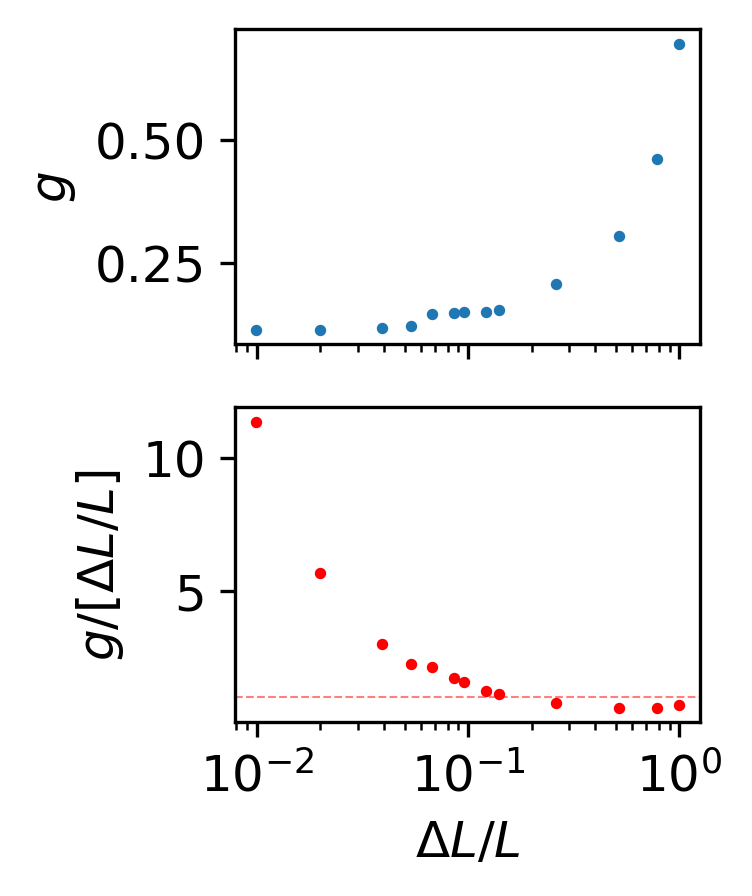

In [8]:
fig, ((ax1, ax2)) = plt.subplots(2, 1, figsize=(2,3), dpi=300, sharex=True)

near_threshold_delta = 0.1  

# Top left plot
ax1.scatter(delta_L_over_L, -np.array(coupling_list), s=3)
ax1.set(
    ylabel=r"$g$",
)

# Bottom left plot
epsilon = 0 # avoids pesky division by zero
ax2.scatter(delta_L_over_L, -np.array(coupling_list)/(np.array(delta_L_over_L)+epsilon), s=3, c='r')
ax2.set(
    xlabel=r"$\Delta L/L$",
    ylabel=r"$g/[\Delta L/L]$",
    xscale='log',
)

ax2.axhline(1, color='r', lw=0.5, alpha=0.5, ls='--')

print("minimum coupling: ", np.min(np.abs(coupling_list)))
print("maximum coupling: ", np.max(np.abs(coupling_list)))
print("mean coupling: ", np.mean(np.abs(coupling_list)))
print("coupling near threshold:", np.mean(np.abs(coupling_list)[np.abs(np.abs(coupling_list)-np.array(delta_L_over_L)) < near_threshold_delta]))


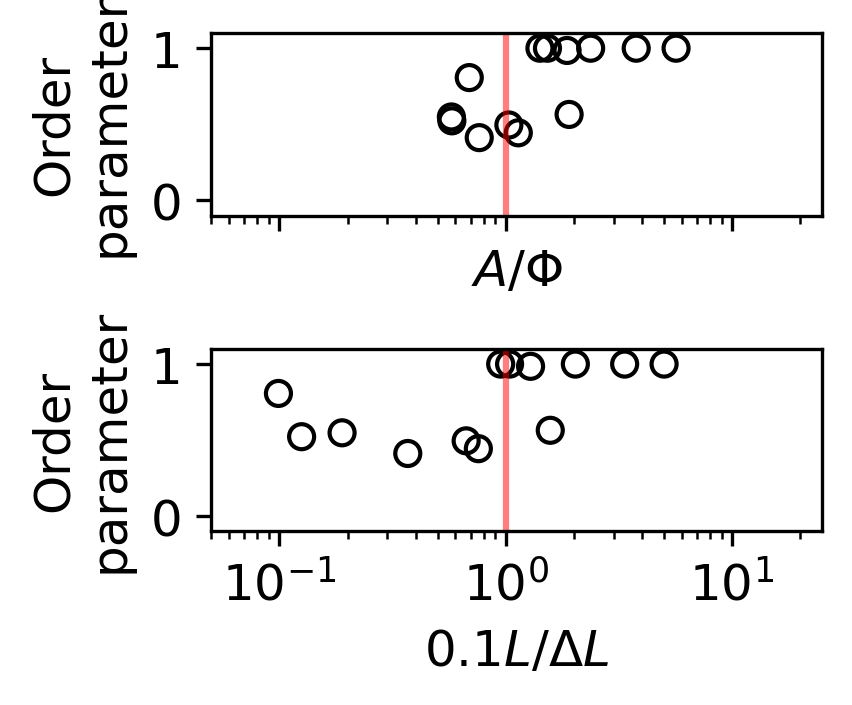

In [9]:
fig, AX = plt.subplots(2,1,figsize=(3,2.5), dpi=300, sharex=True, sharey=True)

ax = AX[0]
epsilon = 1e-2
A_over_Phi = -np.array(coupling_list) / (np.array(delta_L_over_L) + epsilon)

ax.scatter(A_over_Phi, R, marker="o", facecolor="none", edgecolor="k")

ax.set(
    ylabel="Order\nparameter",
    xlabel=r"$A/\Phi$",
    xscale='log',
    xlim=[0.05,25],
    ylim=[0,1.1],
)

ax.axvline(1, color='r', alpha=0.5)

ax = AX[1]
epsilon = 1e-2
A_over_Phi = 0.10 / (np.array(delta_L_over_L) + epsilon)

ax.scatter(A_over_Phi, R, marker="o", facecolor="none", edgecolor="k")

ax.set(
    ylabel="Order\nparameter",
    xlabel=r"$0.1L/\Delta L$",
    xscale='log',
    xlim=[0.05,25],
    ylim=[-0.1,1.1],
)

ax.axvline(1, color='r', alpha=0.5)
fig.savefig('QD_sync.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()


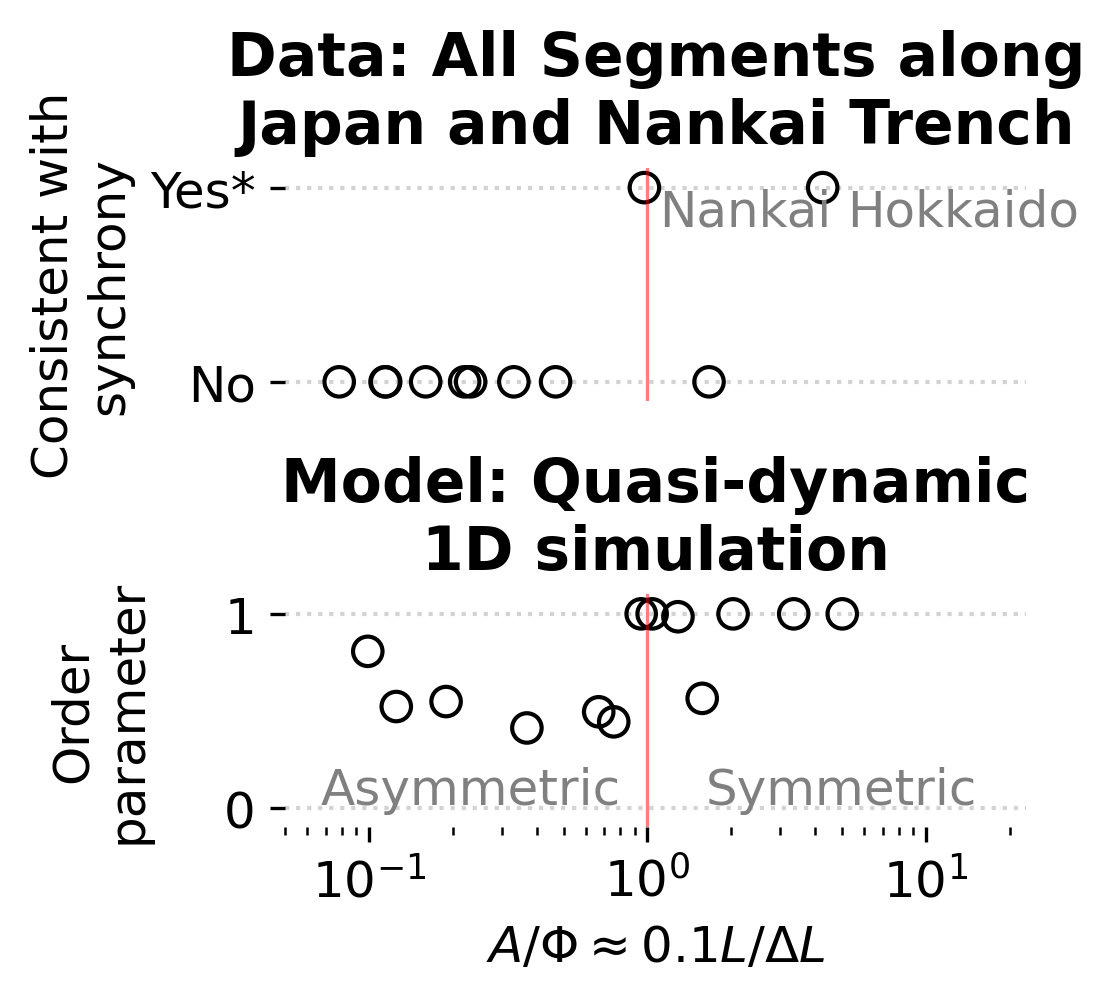

In [10]:
fig, AX = plt.subplots(2, 1, figsize=(3.75, 3.5), dpi=300, sharex=True)

for ax in AX:
    for spine in ax.spines.values():
        spine.set_visible(False)
    h0 = ax.axhline(0, color='lightgrey', lw=1, ls=':')
    h1 = ax.axhline(1, color='lightgrey', lw=1, ls=':')
    h0.set_zorder(0)
    h1.set_zorder(0)

ax = AX[0]
# Observational data:

file_name = "length_data.csv"
df = pd.read_csv(file_name)
df["L1"] = df.L1_raw * df.map_distance / df.measurement_distance
df["L2"] = df.L2_raw * df.map_distance / df.measurement_distance
df["del_L/L"] = np.abs(df.L1 - df.L2) / df[["L1", "L2"]].mean(axis=1)

marker_dict = dict(
    facecolor="none",
    marker="o",
    linewidth=1,
    edgecolor="k",
    s=50,
)

ax.scatter(0.1 / df["del_L/L"], df["sync"], **marker_dict)

ax.set(
    ylim=[-0.1, 1.1],
    yticks=[0, 1],
    yticklabels=["No", r"Yes*"],
    ylabel='Consistent with\nsynchrony'
)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)


ax.set_title("Data: All Segments along\nJapan and Nankai Trench", weight="bold")

text_kwargs = dict(ha="left", va="top", color="grey")
ax.text(1.1, 1, "Nankai", **text_kwargs)
ax.text(5.2, 1, "Hokkaido", **text_kwargs)

ax = AX[1]
# Model outputs:

epsilon = 1e-2
A_over_Phi = 0.10 / (np.array(delta_L_over_L) + epsilon)
ax.scatter(A_over_Phi, R, **marker_dict)

ax.set(
    ylabel="Order\nparameter\n",
    xlabel=r"$A/\Phi \approx 0.1L/\Delta L$",
    xlim=[0.05, 23],
    xscale="log",
    yticks=[0, 1],
    ylim=[-0.1, 1.1],
)

ax.set_title("Model: Quasi-dynamic\n1D simulation", weight='bold')

text_kwargs = dict(ha="center", transform=ax.transAxes, color="grey")
ax.text(0.25, 0.1, "Asymmetric", **text_kwargs)
ax.text(0.75, 0.1, "Symmetric", **text_kwargs)

[ax.axvline(1, color="r", alpha=0.5, lw=0.8) for ax in AX]

for ax in AX:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()